Logistic Regression is a supervised learning algorithm used for binary classification. It models the probability that an observation belongs to the positive class using the logistic (sigmoid) function. The dataset is generated synthetically using `make_classification`.

In [1]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

### Data Visualization and Preparation

Before training our model, it is essential to explore the structure of our dataset. We visualize the two-dimensional features using a scatter plot to observe the linear separability of the two classes. 

Next, we use `train_test_split` to divide our dataset into a **Training Set** (for updating the model's weights) and a **Testing Set** (for evaluating performance on unseen data).

Shape of X: (1000, 2)
Shape of y: (1000,)


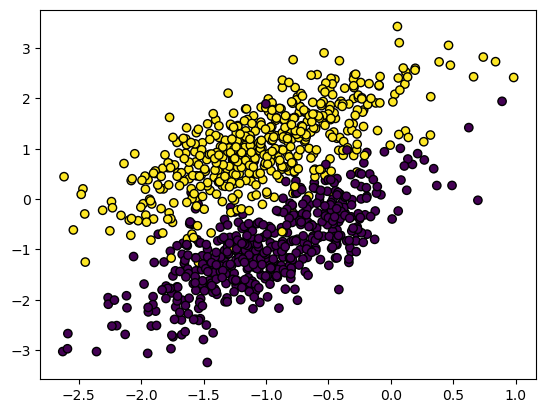

In [2]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=12)

print(f'Shape of X: {X.shape}\nShape of y: {y.shape}')

plt.scatter (X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X train: (800, 2)
y train: (800,)
X test: (200, 2)
y test: (200,)


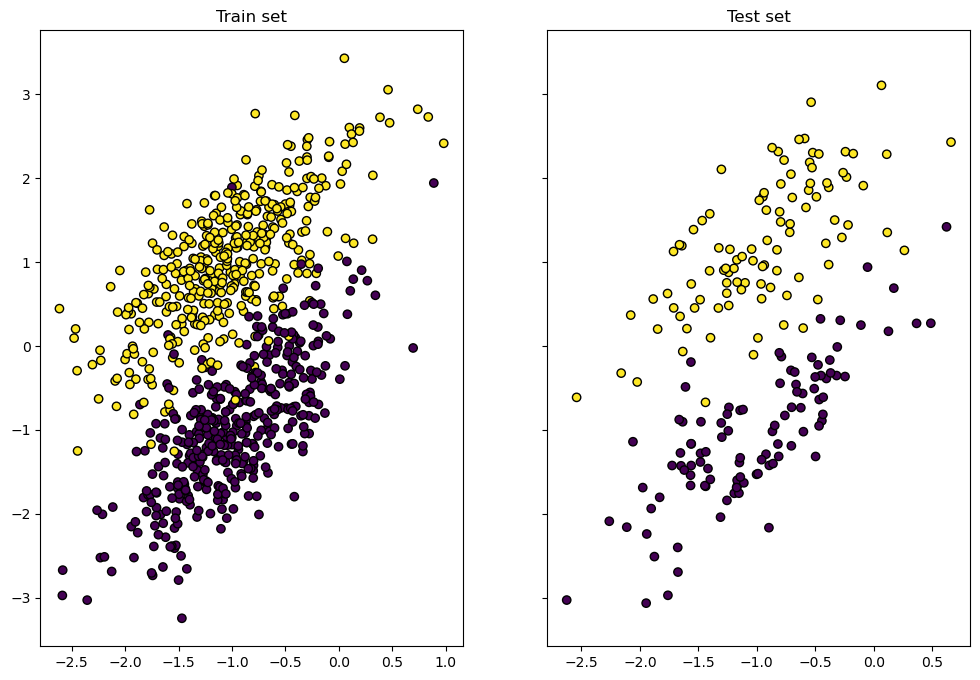

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=12)

print(f'X train: {X_train.shape}\ny train: {y_train.shape}\nX test: {X_test.shape}\ny test: {y_test.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12,8), sharey=True)
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')
axes[0].set_title('Train set')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k')
axes[1].set_title('Test set')
plt.show()

### Mathematical Foundation of Logistic Regression

**1. Hypothesis Representation:**
The model predicts the probability $P(y=1|X)$ by applying the sigmoid function to the linear combination of inputs:
$$\hat{y}=\sigma(XW+b)$$
where the sigmoid function is defined as:
$$\sigma(z)=\frac{1}{1+e^{-z}}$$

**2. Cost Function (Log Loss / Binary Cross-Entropy):**
To train the model, we minimize the cost function, which penalizes incorrect confident predictions:
$$J(W,b)=-\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]$$

**3. Gradient Descent Optimization:**
We update the weights $W$ and bias $b$ iteratively using the gradients of the cost function:
$$dW=\frac{\partial J}{\partial W}=\frac{1}{n}X^T(\hat{y}-y)$$
$$db=\frac{\partial J}{\partial b}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)$$
Update rule with learning rate $\alpha$:
$$W:=W-\alpha\cdot dW$$
$$b:=b-\alpha\cdot db$$

In [5]:
import numpy as np

In [46]:
class MyLogisticRegression:
    def __init__(self, num_iterations=100, learning_rate=0.4):
        self.b = None
        self.weights = None
        self.score = None
        self.num_iterations = num_iterations
        self.learning_rate = learning_rate
        self.losses = None
        
    def fit(self, X, y):
        self.b = 0.0
        self.weights = np.zeros(X.shape[1])
            
        self.losses = list()

        for i in range(self.num_iterations):
            y_hat = self.sigmoid(self.b + X @ self.weights)
            loss = 1/len(y) * np.sum(-y*np.log(y_hat) - (1-y)*np.log(1-y_hat))
            self.losses.append(loss)
            self.b -= 1/len(y) * self.learning_rate * np.sum(y_hat - y)
            self.weights -= 1/len(y) * self.learning_rate * (y_hat - y) @ X 

        self.score = np.sum(y == self.predict(X)) / len(y)

    def sigmoid(self, a):
        return 1/(1+np.exp(-a))

    def predict(self, X, th=0.5):
        return (self.predict_proba(X) >= th).astype(int)

    def predict_proba(self, X):
        return (self.sigmoid(self.b + X @ self.weights))

    def accuracy(self, X, y):
        return np.sum(y == self.predict(X)) / len(y)
        
    def visualize_loss(self):
        xs = np.linspace(start=0, stop=self.num_iterations, num=self.num_iterations)
        plt.plot(xs, self.losses)
        plt.title('Loss function')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.show()

    def score_report(self, X, y):
        y_pred = self.predict(X)
        tp = np.sum((y == 1) & (y_pred == 1))
        tn = np.sum((y == 0) & (y_pred == 0))
        fp = np.sum((y == 0) & (y_pred == 1))
        fn = np.sum((y == 1) & (y_pred == 0))

        acc = (tp + tn) / (tp + tn + fp + fn)
        pr = tp / (tp + fp)
        re = tp / (tp + fn)
        f1 = 2 * pr * re / (pr + re)

        conf_m = np.array([[tp, tn], [fp, fn]])

        print(f'Confusion matrix: \n{conf_m}')
        print(f'Accuracy = {acc}, \nPrecision = {pr}, \nRecall = {re}, \nF1 score = {f1}')

        thresholds = np.linspace(0, 1, 100)
        tpr = list()
        fpr = list()

        probas = self.predict_proba(X)
        for th in thresholds:
            y_pred_th = (probas >= th).astype(int)

            tp = np.sum((y == 1) & (y_pred_th == 1))
            tn = np.sum((y == 0) & (y_pred_th == 0))
            fp = np.sum((y == 0) & (y_pred_th == 1))
            fn = np.sum((y == 1) & (y_pred_th == 0))

            tpr_th = tp / (tp + fn)
            fpr_th = fp / (tn + fp)
            tpr.append(tpr_th)
            fpr.append(fpr_th)

        plt.plot(fpr, tpr)
        plt.title('ROC AUC')
        plt.xlabel('False positive rate (FPR)')
        plt.ylabel('True positive rate (TPR)')
        plt.text(x=0.6, y=0, s=f'AUC score = {np.trapz(y=tpr[::-1], x=fpr[::-1]):.3f}')
        plt.show()



### Classification Metrics and ROC AUC

After training, the model's performance is evaluated using a Confusion Matrix, which categorizes predictions into True Positives ($TP$), True Negatives ($TN$), False Positives ($FP$), and False Negatives ($FN$).

Key metrics are derived from these counts to provide different business insights:

*   **Accuracy:** $\frac{TP+TN}{TP+TN+FP+FN}$

   
    How often is the model correct overall? Best used when classes are balanced.
*   **Precision:** $\frac{TP}{TP+FP}$ 


    Out of all the objects the model predicted as positive, how many are actually positive? Crucial when the cost of a False Positive (false alarm) is high.
*   **Recall (Sensitivity or TPR):** $\frac{TP}{TP+FN}$ 


    Out of all actual positive objects, how many did the model successfully find? Crucial when missing a positive case (False Negative) is dangerous.
*   **F1-Score:** $2\cdot\frac{Precision\cdot Recall}{Precision+Recall}$ 


    The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is especially useful for imbalanced datasets.

The **ROC Curve** (Receiver Operating Characteristic) illustrates the diagnostic ability of the classifier as its discrimination threshold is varied, plotting $TPR$ against False Positive Rate ($FPR=\frac{FP}{FP+TN}$). The **ROC AUC** metric calculates the area under this curve using the trapezoidal rule.

Coefficients:
Weights: [-4.86334896  4.7882938 ]
b: -4.804187306167769
----------Train score------------
Confusion matrix: 
[[384 385]
 [ 15  16]]
Accuracy = 0.96125, 
Precision = 0.9624060150375939, 
Recall = 0.96, 
F1 score = 0.9612015018773467


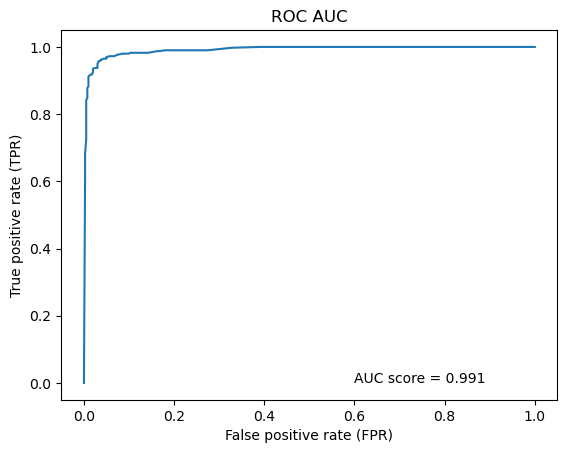

----------Test score------------
Confusion matrix: 
[[ 94 100]
 [  2   4]]
Accuracy = 0.97, 
Precision = 0.9791666666666666, 
Recall = 0.9591836734693877, 
F1 score = 0.9690721649484536


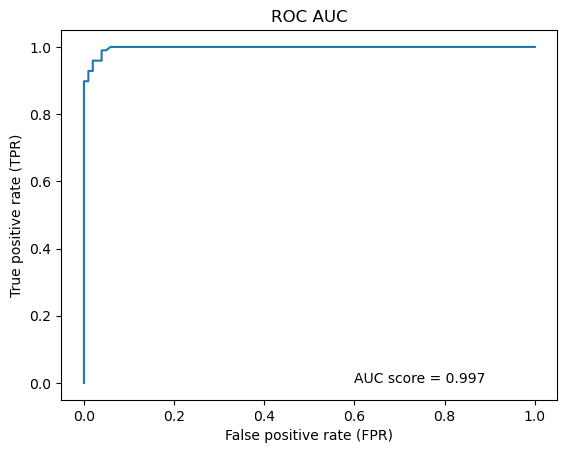

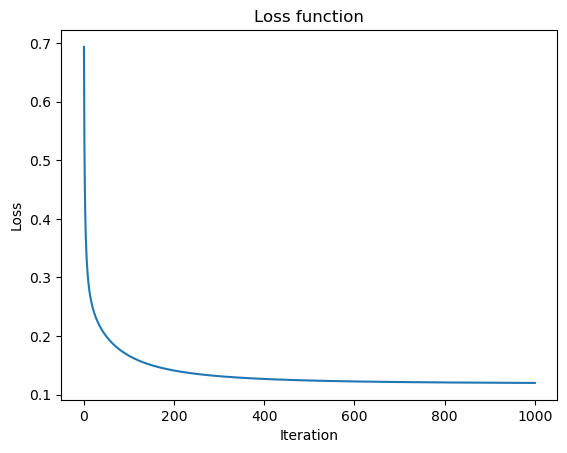

In [47]:
my_log_reg = MyLogisticRegression(num_iterations=1000, learning_rate=0.8)
my_log_reg.fit(X_train, y_train)
print(f'Coefficients:\nWeights: {my_log_reg.weights}\nb: {my_log_reg.b}')

print('----------Train score------------')
my_log_reg.score_report(X_train, y_train)

print('----------Test score------------')
my_log_reg.score_report(X_test, y_test)
my_log_reg.visualize_loss()

In [48]:
from sklearn.linear_model import LogisticRegression

In [53]:
log_reg = LogisticRegression(max_iter=100, penalty=None)
log_reg.fit(X_train, y_train)
print(f'Coefficients:\nWeights: {log_reg.coef_[0]}\nb: {log_reg.intercept_[0]}')

Coefficients:
Weights: [-5.52347253  5.27015899]
b: -5.459227753289147


In [54]:
from sklearn.metrics import classification_report

In [55]:
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

print('----------------Train score-----------------')
print(classification_report(y_train, y_train_pred))


print('----------------Test score-----------------')
print(classification_report(y_test, y_test_pred))

----------------Train score-----------------
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       400
           1       0.96      0.96      0.96       400

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800

----------------Test score-----------------
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       102
           1       0.98      0.96      0.97        98

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



### Conclusion: Custom Implementation vs. Scikit-Learn

As seen in the outputs above, our custom `MyLogisticRegression` model yields results (coefficients, accuracy, and ROC AUC) that are highly comparable to the industry-standard `sklearn.linear_model.LogisticRegression`. 

However, the results are not strictly identical due to differences in the underlying software engineering and mathematical implementations.